In [1]:
import psi4
import numpy as np
from cqed_rhf.calculator import CQEDRHFCalculator
# ─────────────────────────────────────────────
# Psi4 basic config
# ─────────────────────────────────────────────
psi4.set_memory("10 GB")
psi4.set_num_threads(2)
psi4.set_output_file("psi4_env_check.out", False)
psi4.core.clean()
psi4.core.clean_options()



  Memory set to   9.313 GiB by Python driver.
  Threads set to 2 by Python driver.


In [2]:
# Distances along z-axis for Br
br_distances = np.linspace(2.0, 3.5, 20)  # 20 points between 1.4 and 4.0 Å
energies = []


#br_distances = [4.0]
# Geometry of nitrobenzene without Br
base_geom = """
1 1
 C           -1.468931365599     1.178697647085    -1.610476189598
 C           -0.081420645599     1.196870987085    -1.586337729598
 C            0.594038404401    -0.009641582915    -1.487579279598
 C           -2.153305305599    -0.029816812915    -1.536826409598
 H           -2.016475245599     2.111128687085    -1.687252519598
 H            0.478758204401     2.120622867085    -1.641899559598
 H           -3.237744725599    -0.037851282915    -1.556289569598
 N            2.070250494401     0.001301307085    -1.461192949598
 O            2.638548954401    -1.067946332915    -1.375316239598
 O            2.625214324401     1.078933737085    -1.526960829598
 C           -1.454272445599    -1.228165032915    -1.438287069598
 H           -1.990524005599    -2.168537162915    -1.380997049598
 C           -0.066668565599    -1.225978212915    -1.412581159598
 H            0.504648244401    -2.141351302915    -1.336153489598
"""

psi4_options = {"basis": "6-311G*",
                  "reference": "rks",
                  "scf_type": "df",
                  "e_convergence": 1e-9,
                  "d_convergence":1e-9,
                  "dft_radial_points": 99,
                  "dft_spherical_points": 590,
                  "dft_pruning_scheme": "none"
}
    
# Psi4 options
psi4.set_options(psi4_options)


lambda_vector = np.array([0.078, 0.055, 0.027])
omega = 0.06615



calc = CQEDRHFCalculator(
    lambda_vector=lambda_vector,
    psi4_options=psi4_options,
    omega=0.06615,
    charge=1,
    multiplicity=1,
    density_fitting=True,
    functional="wb97x-d",
    debug=True,
)

# note -0.650118399399     0.016971049385     2.324047987802 is the geometry from Avagadro manipulation

for z in br_distances:
    geom_str = base_geom + f"Br -0.650118399399     0.016971049385  {z:.3f}\nunits angstrom\nno_com\nno_reorient\nsymmetry c1"
    mol = psi4.geometry(geom_str)
    E = calc.energy(geom_str)
    energies.append(E)
    print(f"Distance {z:.2f} Å: Energy = {E:.8f} Hartree")

# UKS results
#Distance 2.00 Å: Energy = -3010.34004850 Hartree
#Distance 2.50 Å: Energy = -3010.41880905 Hartree
#Distance 3.00 Å: Energy = -3010.42316702 Hartree
#Distance 3.50 Å: Energy = -3010.41105499 Hartree




Running CQED-SCF energy calculation...

Functional: wb97x
Starting CQED-SCF calculation...
Method: RKS
Functional: wb97x
Using density fitting through Psi4 JK.
Functional info:
  x_alpha = 0.157706
  x_beta  = 0.842294
  x_omega = 0.3
CQED Iter   1: E =   -3010.1946333884  dE = -3.01019463e+03  dRMS =  2.81034051e-04
  E_H =   -5548.8124652972
  E_Exc =    -113.3296102388
  E_J =    1988.4774970144
  E_K =     -22.8754806711
  E_wK =     -13.1407812808
  E_N =      -2.6653273923
CQED Iter   2: E =   -3010.2001820299  dE = -5.54864151e-03  dRMS =  5.39829778e-05
  E_H =   -5549.4083162971
  E_Exc =    -113.3690241498
  E_J =    1989.1308477040
  E_K =     -22.8845467698
  E_wK =     -13.1473440806
  E_N =      -2.6733329140
CQED Iter   3: E =   -3010.2006461591  dE = -4.64129188e-04  dRMS =  2.79004857e-05
  E_H =   -5549.3508262707
  E_Exc =    -113.3618521260
  E_J =    1989.0652562444
  E_K =     -22.8833409471
  E_wK =     -13.1473840217
  E_N =      -2.6740335154
CQED Iter   4: E 

SCFConvergenceError: Could not converge SCF iterations in 100 iterations.

In [3]:
#br_distances = np.linspace(2.0, 4.0, 5)  # 20 points between 1.4 and 4.0 Å

# 2️⃣ Find minimum distance from the scan
min_index_s = np.argmin(energies)
min_distance = br_distances[min_index_s]
print(f"\nApproximate minimum for RKS singlates at z = {min_distance:.2f} with energy {energies[min_index_s]:.8f} Hartree")

#min_index_s_uks = np.argmin(energies_sing_uks)
#min_distance_s_uks = br_distances[min_index_s_uks]
#print(f"\nApproximate minimum for UKS singlates at z = {min_distance_s_uks:.2f} with energy {energies[min_index_s_uks]:.8f} Hartree")

#min_index_t = np.argmin(energies_triplet)
#min_distance_t = br_distances[min_index_t]
#print(f"\nApproximate minimum for triplates at z = {min_distance_t:.2f} with energy {energies_triplet[min_index_t]:.8f} Hartree")



# 3️⃣ Single-point calculation at 6-311G* at the minimum
#psi4.set_options({"basis": "6-311G*",
#                  "reference": "uhf",
#                  "scf_type": "df",
#                  "e_convergence": 1e-6})

# min_geom = base_geom + f"Br 0.000000 0.000000 {min_distance:.3f}\nunits angstrom\nsymmetry c1"
# min_mol = psi4.geometry(min_geom)
# e_6311G = psi4.energy("b3lyp", molecule=min_mol)
# print(f"\nSingle-point energy at minimum with 6-311G* for = {e_6311G:.8f} Hartree")




Approximate minimum for RKS singlates at z = 2.00 with energy -3010.20981814 Hartree


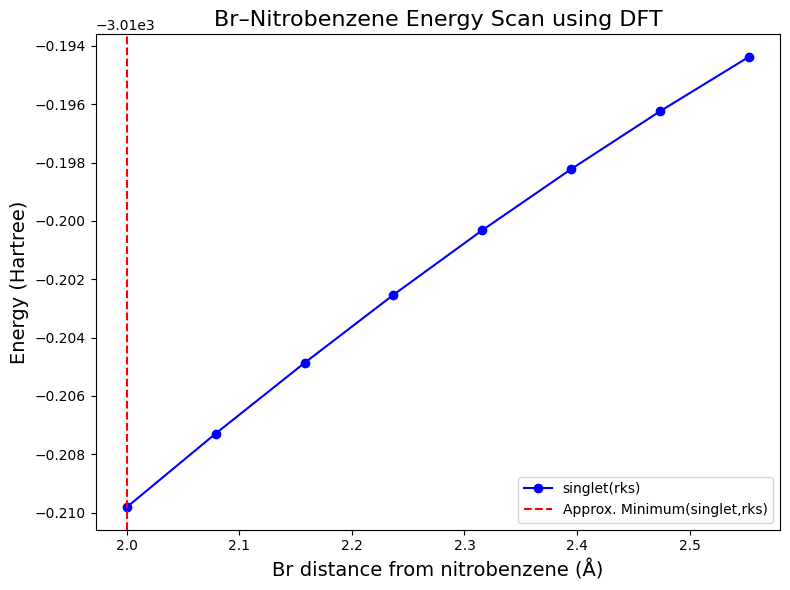

In [5]:
import matplotlib.pyplot as plt
# 4️⃣ Plot scan
plt.figure(figsize=(8,6))
plt.plot(br_distances[:8], energies, marker='o', linestyle='-', color='b', label='singlet(rks)')
#plt.plot(br_distances, energies_sing_uks, marker='s', linestyle='--', color='g', label='singlet(uks)')
plt.axvline(min_distance, color='r', linestyle='--', label='Approx. Minimum(singlet,rks)')
#plt.axvline(min_distance_s_uks, color='m', linestyle='--', label='Approx. Minimum (singlet,uks)')
plt.xlabel("Br distance from nitrobenzene (Å)", fontsize=14)
plt.ylabel("Energy (Hartree)", fontsize=14)
plt.title("Br–Nitrobenzene Energy Scan using DFT", fontsize=16)
#plt.savefig("/Users/rmandern/code/md-cqed/br_nitrobenzene_wb97xd_uks.png", dpi=300)
# plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(energies)